Install XGBoost

In [ ]:
!pip -q install xgboost

Imports Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor


Load dataset

In [ ]:
df = pd.read_csv("/content/Final_MasterDataset.csv")
print("Loaded:", df.shape)
print(df.columns.tolist())


Loaded: (155, 19)
['Country', 'Year', 'D_Expenditure_GDP', 'Conflict_Intensity', 'Health_Expenditure_(% of GDP)', 'Education_Expenditure_(% of GDP)', 'Environmental_impact(CO2e/capita)', 'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)\n', 'Refugees', 'Asylum Seekers', 'Total number of deaths', 'Population', 'GDP_Growth_Annual', 'GDP_PerCapita_Growth_Annual', 'GDP_Current_USDollars', 'Inflation_Annual', 'Unemployment_Total_of_TLF', 'Unemployment_Male_of_TMF', 'Unemployment_Female_of_TFF']


Define features and target columns

In [ ]:
features = ["D_Expenditure_GDP", "Year", "Country"]

targets = {
    "Health_Expenditure_(% of GDP)": "Health",
    "Education_Expenditure_(% of GDP)": "Education"
}


Train & evaluate function (for one target)

In [ ]:
def run_xgb_for_target(target_col, label):

    # Keep only needed columns and remove missing rows
    data = df[features + [target_col]].dropna()
    X = data[features]
    y = data[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["Country"]),
            ("num", "passthrough", ["D_Expenditure_GDP", "Year"]),
        ]
    )

    # create XGBoost model
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    )

    model = Pipeline([
        ("prep", preprocess),
        ("xgb", xgb)
    ])

    # Train Model & predict
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    print(f"\n================ {label.upper()} (XGBOOST) ================")
    print("Rows used:", len(data))
    print("Train rows:", len(X_train), "| Test rows:", len(X_test))
    print("R² :", round(r2, 4))
    print("MAE:", round(mae, 4))
    print("MSE:", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("===========================================================")

    # Plot Actual vs Predicted values
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, pred, alpha=0.6, label="Predictions")

    lim_min = min(y_test.min(), pred.min())
    lim_max = max(y_test.max(), pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], color="red", label="Perfect Fit")

    plt.xlabel(f"Actual {label} Expenditure (% GDP)")
    plt.ylabel(f"Predicted {label} Expenditure (% GDP)")
    plt.title(f"Actual vs Predicted ({label}) - XGBoost")
    plt.grid(True)
    plt.legend()
    plt.show()

    return {"Target": label, "R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}



================ HEALTH (XGBOOST) ================
Rows used: 116
Train rows: 92 | Test rows: 24
R² : 0.9922
MAE: 0.2613
MSE: 0.1341
RMSE: 0.3661


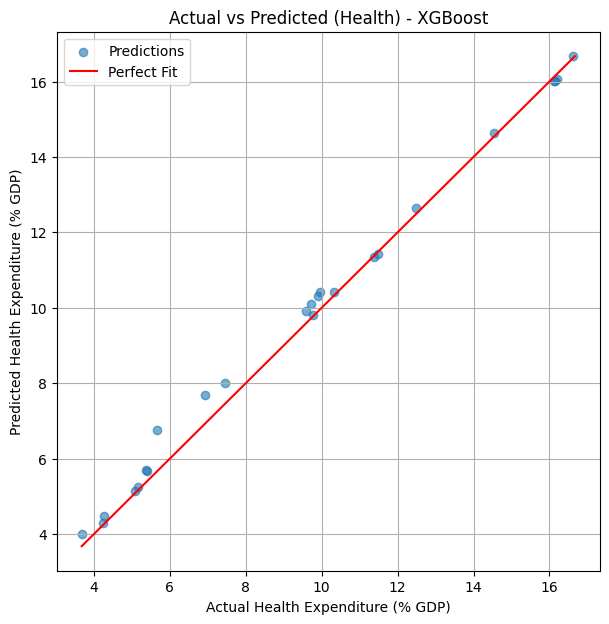


================ EDUCATION (XGBOOST) ================
Rows used: 125
Train rows: 100 | Test rows: 25
R² : 0.908
MAE: 0.2627
MSE: 0.1257
RMSE: 0.3546


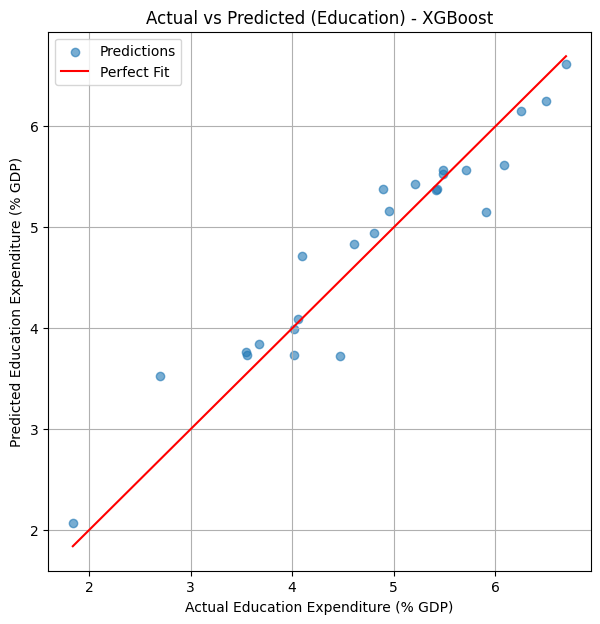


=== XGBoost Comparison Table ===
   Target     R2    MAE    MSE   RMSE
   Health 0.9922 0.2613 0.1341 0.3661
Education 0.9080 0.2627 0.1257 0.3546


In [ ]:
results = []
for target_col, label in targets.items():
    results.append(run_xgb_for_target(target_col, label))

comparison = pd.DataFrame(results)
print("\n=== XGBoost Comparison Table ===")
print(comparison.round(4).to_string(index=False))


In [ ]:
comparison = pd.DataFrame(results)[["Target", "R2", "MAE", "MSE", "RMSE"]].copy()

comparison = comparison.rename(columns={
    "R2": "R²",
    "MAE": "MAE",
    "MSE": "MSE",
    "RMSE": "RMSE"
})

print("\n=== XGBoost Comparison Table ===")
print(comparison.round(4).to_string(index=False))



=== XGBoost Comparison Table ===
   Target     R²    MAE    MSE   RMSE
   Health 0.9922 0.2613 0.1341 0.3661
Education 0.9080 0.2627 0.1257 0.3546
